In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

data_table = "../data/PeCa_Final_Included_freeze_2026-02-26.csv"
df_original = pd.read_csv(data_table, delimiter=",")
df_original.columns

Index(['Original_Index', 'Index', 'Title', 'Abstract', 'Authors', 'PubmedID',
       'DOI', 'Year', 'Publication Types', 'Article Type',
       'Publication Status', 'Country/region of selected patients',
       'Sample size by the biomarker assessed',
       'Number of penile cancer cases', 'Number of other cases',
       'Median age of patients', 'Mean age of patients',
       'Follow-up time mo (mean)', 'Follow-up time mo (median)', 'pTNM',
       'Stage', 'Grade', 'Surgery', 'Oncologic treatment', 'Radiotherapy',
       'Information on HPV status of all patients', 'Biomarker name',
       'Area of the biomarker',
       'Biomarker info (overexpression/hypermethylation/loss etc.)',
       'Biomarker category', 'TMA', 'Detection method', 'Scoring method',
       'Cut-off definition/positivity',
       'Tissue sample location (Primary, Lymph Node/Metastasis)',
       'Survival outcome investigated', 'HR, CI univariate analysis',
       'HR, CI multivariate analysis', 'Survival outcome

In [2]:
df = df_original.copy()

MISSING_MARKERS = [
    "-", "—", "–", "", "NA", "N/A", "n/a", "na", "None", "none", "Not reported"
]

cols = [
    'HR, CI univariate analysis',
    'HR, CI multivariate analysis'
]

df[cols] = (
    df[cols]
    .replace(MISSING_MARKERS, np.nan)
)

def extract_hr(value):
    if pd.isna(value):
        return np.nan
    text = str(value).replace(',', '.')
    match = re.match(r'\s*([0-9]*\.?[0-9]+)', text)
    return float(match.group(1)) if match else np.nan

def extract_ci_low(value):
    if pd.isna(value):
        return np.nan
    text = str(value).replace(',', '.')
    match = re.search(r'\s*\(\s*([0-9]*\.?[0-9]+)\s*-\s*([0-9]*\.?[0-9]+)\s*\)', text)
    return float(match.group(1)) if match else np.nan

def extract_ci_high(value):
    if pd.isna(value):
        return np.nan
    text = str(value).replace(',', '.')
    match = re.search(r'\s*\(\s*([0-9]*\.?[0-9]+)\s*-\s*([0-9]*\.?[0-9]+)\s*\)', text)
    return float(match.group(2)) if match else np.nan

df['HR_value_univariate'] = df['HR, CI univariate analysis'].apply(extract_hr)
df['CI_low_univariate'] = df['HR, CI univariate analysis'].apply(extract_ci_low)
df['CI_high_univariate'] = df['HR, CI univariate analysis'].apply(extract_ci_high)

df['HR_value_multivariate'] = df['HR, CI multivariate analysis'].apply(extract_hr)
df['CI_low_multivariate'] = df['HR, CI multivariate analysis'].apply(extract_ci_low)
df['CI_high_multivariate'] = df['HR, CI multivariate analysis'].apply(extract_ci_high)

In [3]:
import numpy as np

# pick multivariate if present, else univariate
use_multi = df["HR_value_multivariate"].notna()

df["HR_pick"] = np.where(use_multi, df["HR_value_multivariate"], df["HR_value_univariate"])
df["CI_low_pick"] = np.where(use_multi, df["CI_low_multivariate"], df["CI_low_univariate"])
df["CI_high_pick"] = np.where(use_multi, df["CI_high_multivariate"], df["CI_high_univariate"])

# Record which type was used
df["HR_picked_from"] = np.where(
    use_multi, "Multivariate",
    np.where(df["HR_value_univariate"].notna(), "Univariate", None)
)

# log(HR) and SE from 95% CI
problematic = df[
    (df["HR_pick"].notna()) &
    (df["HR_pick"] <= 0)
]
print("These articles have a HR of zero:\n",
    problematic[
    ["PubmedID", "Biomarker name", "HR_pick",
     "HR, CI univariate analysis", "HR, CI multivariate analysis"]
])

df["yi"] = np.log(df["HR_pick"])
df["sei"] = (np.log(df["CI_high_pick"]) - np.log(df["CI_low_pick"])) / (2 * 1.96)
df["vi"] = df["sei"]**2

# Set the stats for the problematic entries to NaN
df.loc[
    (df["HR_pick"] <= 0) |
    (df["CI_low_pick"] <= 0) |
    (df["CI_high_pick"] <= 0),
    ["yi", "sei"]
] = np.nan

print(df[
    ['PubmedID', 'HR_pick', 'yi', 'sei']
      ].head(5))

These articles have a HR of zero:
        PubmedID         Biomarker name  HR_pick HR, CI univariate analysis  \
105  39810000.0                  CD138      0.0                0.0 (0-inf)   
489  29942303.0  Classical HLA Class 1      0.0           0.00 (0.00–0.00)   
660  39810000.0                  PD-L1      0.0                0.0 (0-inf)   

    HR, CI multivariate analysis  
105                          NaN  
489                          NaN  
660                          NaN  
     PubmedID  HR_pick        yi       sei
0  40327767.0      NaN       NaN       NaN
1  40327767.0      NaN       NaN       NaN
2  40327767.0      NaN       NaN       NaN
3  40308599.0    2.028  0.707050  0.322103
4  40308599.0    2.911  1.068497  0.415665


/Users/niemeyfr/Library/Caches/pypoetry/virtualenvs/peca-sys-review-MqYnM_h9-py3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [4]:
df[
    ["HR_picked_from", "HR_pick", "CI_low_pick", "CI_high_pick", 'yi', 'sei', 'vi', 'HR, CI univariate analysis', 'HR_value_univariate', 'CI_low_univariate', 'CI_high_univariate', 'HR, CI multivariate analysis', 'HR_value_multivariate', 'CI_low_multivariate', 'CI_high_multivariate']
].head(5)

,HR_picked_from,HR_pick,CI_low_pick,CI_high_pick,yi,sei,vi,"HR, CI univariate analysis",HR_value_univariate,CI_low_univariate,CI_high_univariate,"HR, CI multivariate analysis",HR_value_multivariate,CI_low_multivariate,CI_high_multivariate
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Univariate,2.028,1.079,3.814,0.707050,0.322103,0.103750,2.028 (1.079-3.814),2.028,1.079,3.814,NaN,NaN,NaN,NaN
4,Univariate,2.911,1.289,6.575,1.068497,0.415665,0.172778,2.911 (1.289-6.575),2.911,1.289,6.575,NaN,NaN,NaN,NaN


In [5]:
def parse_p_value(x, substitute="minus0.00001"):
    if pd.isna(x):
        return np.nan, False, np.nan

    s = str(x).strip().lower()
    s = s.replace(",", ".")

    # match <0.05, <0.01, <=0.01, < 1e-3
    m = re.match(r"(<=|<|≤)\s*([0-9]*\.?[0-9]+(?:e-?\d+)?)", s)
    if m:
        thresh = float(m.group(2))
        if substitute == "half":
            return thresh / 2, True, thresh
        elif substitute == "minus0.00001":
            return thresh - .00001, True, thresh
        elif substitute == "threshold":
            return thresh, True, thresh

    try:
        if s == .0:
            s = 1e-10
        return float(s), False, np.nan
    except ValueError:
        return np.nan, False, np.nan

In [6]:
# Use the p-value corresponding to picked HR
df['P_value_pick'] = np.where(
    df['HR_picked_from'] == 'Multivariate',
    df['P-values (multivariate analysis)'],
    df['P-values (univariate analysis)']
)

parsed = df["P_value_pick"].apply(parse_p_value)

df["P_value_num"]       = parsed.apply(lambda x: x[0])
df["P_value_censored"]  = parsed.apply(lambda x: x[1])
df["P_value_threshold"] = parsed.apply(lambda x: x[2])

df[["P_value_pick", "P_value_num", "P_value_censored", "P_value_threshold"]].head(10)

,P_value_pick,P_value_num,P_value_censored,P_value_threshold
0,-,NaN,False,NaN
1,-,NaN,False,NaN
2,-,NaN,False,NaN
3,0.028,0.028,False,NaN
4,0.01,0.010,False,NaN
5,0.085,0.085,False,NaN
6,0.01,0.010,False,NaN
7,0.175,0.175,False,NaN
8,0.033,0.033,False,NaN
9,0.49,0.490,False,NaN


In [7]:
df['Survival outcome investigated'].value_counts()

Survival outcome investigated
DSS                          205
OS                           170
CSS                           99
RFS                           47
DFS                           27
MFS                           20
PFS                           14
mOS                           11
mPFS                          11
5-year CSS rate               11
5-year OS                     11
TSS                            9
Cancer-related mortality       8
Overall mortality              8
EFS                            5
3-year CSS                     5
10-year OS                     4
DSS, PFS                       3
Cancer-specific mortality      3
5-year OS rate                 3
5-year CSS                     2
3-year OS rate                 1
5-year CSS                     1
Name: count, dtype: int64

In [8]:
import re

def normalize_survival_outcome(x):
    if pd.isna(x):
        return x

    s = str(x).strip().lower()

    # --- DSS (cancer/disease specific survival) ---
    if re.search(r"\b(css|dss|tss|disease[-\s]?specific)\b", s):
        return "CSS"

    # --- CRM (cancer-related mortality / cancer-specific mortality) ---
    if re.search(r"\b(crm|csm|cancer[-\s]?specific|cancer[-\s]?related[-\s]?mortality)\b", s):
        return "CRM"

    # --- PFS ---
    if re.search(r"\b(pfs|mpfs|progression[-\s]?free)\b", s):
        return "PFS"

    # --- DFS ---
    if re.search(r"\b(dfs|rfs|efs|disease[-\s]?free|recurrence[-\s]?free)\b", s):
        return "DFS"

    # --- OS ---
    if re.search(r"\b(os|mos|overall survival)\b", s):
        return "OS"

    # --- OM ---
    if re.search(r"\b(overall mortality)\b", s):
        return "OM"

    # --- generic survival fallback ---
    if re.search(r"\bsurvival\b", s):
        return "OS"

    # fallback: keep original
    return str(x).strip()

df["Survival outcome standardized"] = (
    df["Survival outcome investigated"]
        .apply(normalize_survival_outcome)
)

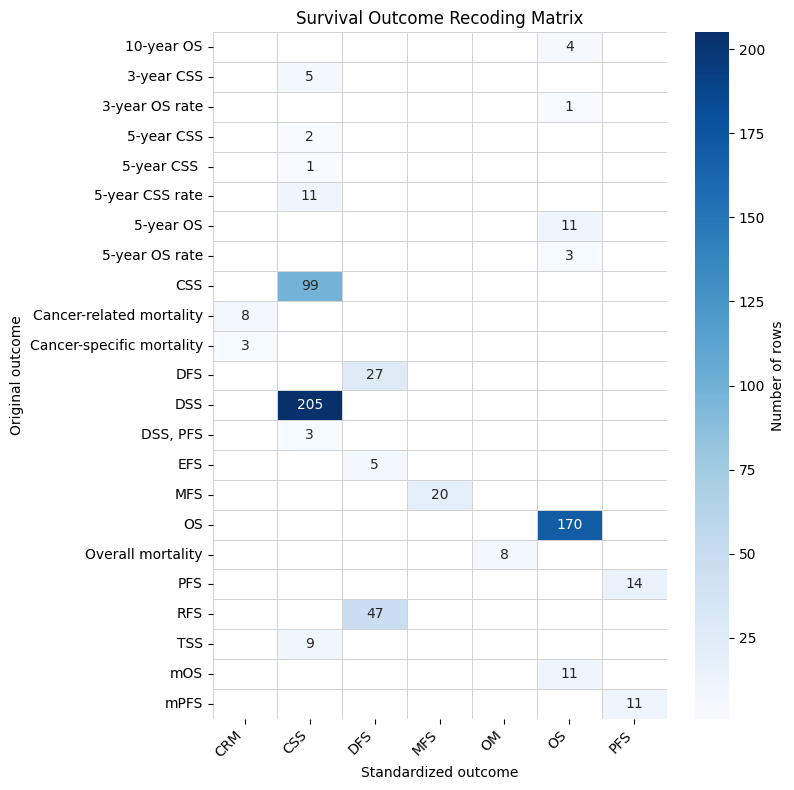

In [9]:
ct = pd.crosstab(
    df["Survival outcome investigated"],
    df["Survival outcome standardized"]
)

# Mask zeros
mask = ct == 0

plt.figure(figsize=(8, 8))

sns.heatmap(
    ct,
    mask=mask,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="lightgrey",
    cbar_kws={"label": "Number of rows"}
)

plt.xlabel("Standardized outcome")
plt.ylabel("Original outcome")
plt.title("Survival Outcome Recoding Matrix")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/outcome_recoding.pdf", bbox_inches="tight")
plt.savefig("figures/outcome_recoding.png", dpi=600, bbox_inches="tight")
plt.show()

Also plot the recoding matrix showing only outcomes from studies that reported a hazard ratio.

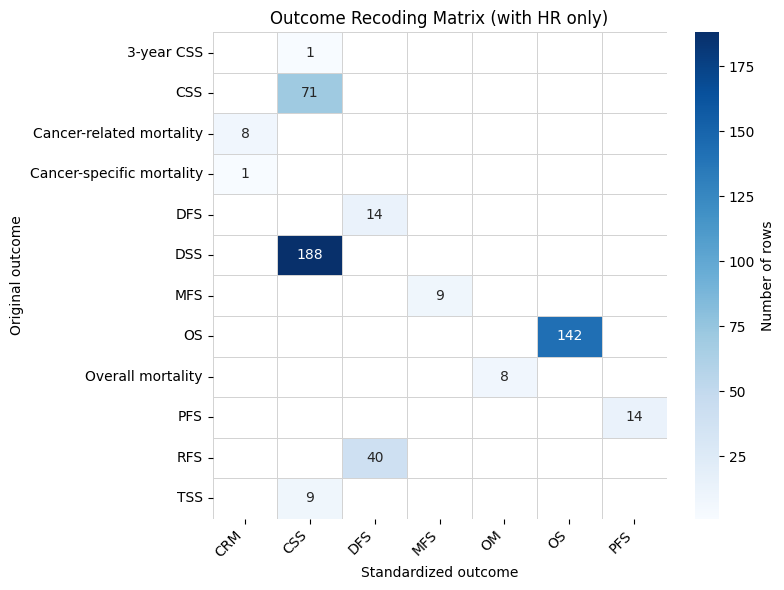

In [10]:
subset_hr = df[~pd.isna(df["HR_pick"])].copy()
subset_hr.head()

ct = pd.crosstab(
    subset_hr["Survival outcome investigated"],
    subset_hr["Survival outcome standardized"]
)

# Mask zeros
mask = ct == 0

plt.figure(figsize=(8, 6))

sns.heatmap(
    ct,
    mask=mask,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="lightgrey",
    cbar_kws={"label": "Number of rows"}
)

plt.xlabel("Standardized outcome")
plt.ylabel("Original outcome")
plt.title("Outcome Recoding Matrix (with HR only)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/outcome_recoding_HR.pdf", bbox_inches="tight")
plt.savefig("figures/outcome_recoding_HR.png", dpi=600, bbox_inches="tight")
plt.show()

In [11]:
df["Survival outcome standardized"].value_counts()

Survival outcome standardized
CSS    335
OS     200
DFS     79
PFS     25
MFS     20
CRM     11
OM       8
Name: count, dtype: int64

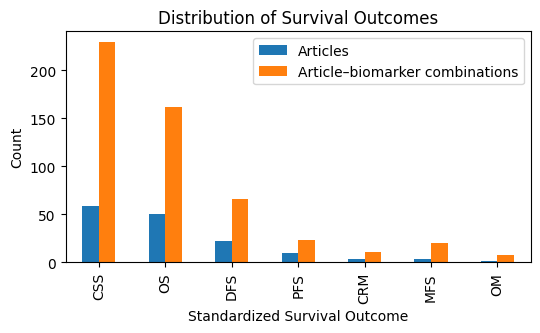

In [12]:
# Article–outcome level
article_outcomes = (
    df.drop_duplicates(['PubmedID', "Survival outcome standardized"])
      ["Survival outcome standardized"]
      .value_counts()
)

# Article–biomarker–outcome level
biomarker_outcomes = (
    df.drop_duplicates(['PubmedID', 'Biomarker name', 'Area of the biomarker', "Survival outcome standardized"])
      ["Survival outcome standardized"]
      .value_counts()
)

# Combine into a single DataFrame for plotting
outcome_counts = (
    pd.concat(
        [article_outcomes, biomarker_outcomes],
        axis=1,
        keys=['Articles', 'Article–biomarker combinations']
    )
    .fillna(0)
    .astype(int)
)

outcome_counts.plot(kind='bar', figsize=(6, 3))
plt.xlabel("Standardized Survival Outcome")
plt.ylabel("Count")
plt.title("Distribution of Survival Outcomes")
plt.savefig("figures/outcomes.pdf", bbox_inches="tight")
plt.savefig("figures/outcomes.png", dpi=600, bbox_inches="tight")

In [13]:
# Normalize biomarker names
df['Biomarker name'] = df['Biomarker name'].replace({
    "non-classical HLA Class 1": "Non-classical HLA Class 1",
    "t-cell ratio": "T-Cell ratio"
})

In [14]:
def parse_sample_size(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip()

    if s.lower().startswith("could"):
        return np.nan

    # handle e.g. "45+12"
    if "+" in s:
        parts = re.findall(r"\d+", s)
        return sum(map(int, parts)) if parts else np.nan

    m = re.search(r"\d+", s)
    return int(m.group()) if m else np.nan

In [15]:
df["Sample_size_biomarker"] = (
    df["Sample size by the biomarker assessed"]
    .apply(parse_sample_size)
)

df["n_penile"] = df["Number of penile cancer cases"].apply(parse_sample_size)
df["n_other"]  = df["Number of other cases"].apply(parse_sample_size)
df["n_total"] = df["n_penile"] + df["n_other"]

In [16]:
df.to_csv('../data/preprocessed_data.csv', index=False)